# Ville de Kourou

# 0. Configuration

In [3]:
# !pip install osmnx
# !pip install scikit-image

In [1]:
import os
import sys
import numpy as np
import geopandas as gpd
import ee
import matplotlib.pyplot as plt

# personal modules
sys.path.insert(1, '../../marion/corridor_project/modules/')
import landcover as lc
import connectivity as conn
import routing as rout
import vizu_ind as viz
sys.path.insert(1, '../../marion/corridor_project/config/')
import species_params

# Authentification GEE
service_account = 'gee-141@gee161025.iam.gserviceaccount.com'
credentials_path = '../../marion/credentials/gee161025-533af22f806b.json'
credentials = ee.ServiceAccountCredentials(service_account, credentials_path)
ee.Initialize(credentials)

# case study def
CITY = "Kourou"
GUILD_KEY = "mammal_edge"
specie = species_params.SPECIES_CONFIG[GUILD_KEY]
OUTPUT_DIR = f"/home/jovyan/work/team/marion/corridor_project/results_connectivity/{CITY}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Paramètres AOI
sys.path.insert(1, '../../Hugo/a_b_c_functions/')
from spatial_analysis.utils_vector import gdf_to_bbox
from OSM.get_boundary import get_boundary
aoi_raw = get_boundary('Kourou')

Matplotlib created a temporary cache directory at /tmp/matplotlib-8uz7p8h6 because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
import importlib
from modules import landcover as lc
from modules import connectivity as conn
from modules import routing as rout
from modules import vizu_ind as viz
import species_params
importlib.reload(lc)
importlib.reload(conn)
importlib.reload(rout)
importlib.reload(viz)
importlib.reload(species_params)

<module 'species_params' from '/home/jovyan/work/team/marion/corridor_project/../../marion/corridor_project/config/species_params.py'>

In [3]:
# display(species_params.get_summary_df())
# df = species_params.prepare_data(species_params.SPECIES_CONFIG)
# species_params.plot_friction_by_guild(df)
# species_params.plot_friction_by_landcover(df)

In [4]:
aoi_utm, aoi_ee, utm_epsg = lc.setup_aoi(aoi_raw)
total_area_km2 = aoi_utm.area.sum() / 1e6
print(total_area_km2)

2288.572239460041


# 1. Landcover

Landcover raster combining ESA WorldCover and OSM

In [5]:
da_lc = lc.get_city_landcover(aoi_ee, aoi_utm, aoi_raw, utm_epsg, specie['habitat_codes'])
print(f"Valeurs : {np.unique(da_lc.values)}")

# da_export = da_lc.fillna(0).astype('uint8')
# da_export.rio.to_raster(f"{OUTPUT_DIR}/landcover_{CITY}.tif")

/opt/conda/lib/python3.11/site-packages/xee/ext.py:685: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


Valeurs : [10. 20. 30. 40. 50. 51. 52. 53. 54. 60. 80. 90. 95. nan]


# 2. Habitat Morphology - MSPA

Identifies morphological connectivity elements (nodes and stepping stones) based on species preferences

In [6]:
binary_wc = conn.get_binary_habitat(da_lc, specie['habitat_codes'])

gdf_cores, gdf_islets = conn.get_connectivity_elements(binary_wc, core_min_ha=1.0, islet_min_ha=0.1)
print(f"✓ {len(gdf_cores)} Noyaux de biodiversité et {len(gdf_islets)} Stepping Stones (Islets + Petits Cores) identifiés.")
if len(gdf_islets) > 0:
    print(gdf_islets['class'].value_counts())
    
# binary_wc.rio.to_raster(f"{OUTPUT_DIR}/binary_habitat_{CITY}.tif")
# gdf_cores.set_crs(utm_epsg, inplace=True, allow_override=True)
# gdf_islets.set_crs(utm_epsg, inplace=True, allow_override=True)
# gdf_cores.to_file(f"{OUTPUT_DIR}/cores_{CITY}.json", driver='GeoJSON')
# gdf_islets.to_file(f"{OUTPUT_DIR}/islets_{CITY}.json", driver='GeoJSON')

✓ 41 Noyaux de biodiversité et 420 Stepping Stones (Islets + Petits Cores) identifiés.
class
Stepping Stone (Small Core)    282
Stepping Stone (Islet)         138
Name: count, dtype: int64


# 3. Graph Connectivity Analysis

## 3.1. Network modeling

The landscape is modeled as a graph where Nodes represent habitat patches and Edges represent potential dispersal links.
- Probabilistic approach: Connection strength is based on an exponential decay function relative to the species dispersal distance ($d_0$) - probability of movement between patches.
  > what i tried: K-nearest neighbors graph (feels forced, too little or too far, no distance involved), Relative neighborhood graph (too restrictive, no loops), Gabriel graph (capture local neighborhood, redundancy allowed)

  
- Gabriel graph is the approach adopted, seems to be the better trade-off
     - **Step 1**: To be quicker, it doesn't check every habitat against every other one but it looks at a patch and search for other patches at ($2 \times d0$) of it. It calculates the Edge-to-Edge distance (instead of centroid-to-centroid).
     - **Step 2**: The Gabriel Filter (= shortcuts rule), it draws an imaginary circle where the path between A and B is the diameter. If there is another Habitat C inside that circle, the path between A and B is deleted.
     - **Step 3**: If a path survives the filter, it calculates how likely it is to actually make the trip:
        1. Probability ($prob$): It uses an exponential decay, the further the distance, the lower the chance of movement.
        2. Cost: It converts that probability into a "cost" (logarithm), to find the shortest/safest path. 

In [7]:
df_nodes = conn.prepare_graph_nodes(gdf_cores, gdf_islets)
# G_knn = conn.build_connectivity_graph_knn(df_nodes, specie)
# G_rng = conn.build_rng_graph(df_nodes, specie)
G = conn.build_gabriel_graph(df_nodes, specie)

Étape 2/2: Filtrage Gabriel: 100%|██████████| 9456/9456 [00:04<00:00, 1893.69it/s]

Graphe de Gabriel construit : 461 nœuds et 761 arêtes.


## 3.2. Theoretical PC index

Probability of Connectivity (PC) Index measures landscape permeability for a given functional guild. It represents the probability that 2 points randomly placed in the city fall within connected habitat patches.
> Remark: Now that we use edge-to-edge instead of centroids, the internal distance is not taken into account, this can overestimates connectivity beacuse it ignores the space occupied by the patch itself  
> Assumption: movement inside patches is free  

In [8]:
total_area_km2 = aoi_utm.area.sum() / 1e6
pc_value = conn.calculate_pc_index(G, total_area_km2)
print(f"Indice PC pour {CITY} : {pc_value:.4f}")

gdf_edges = conn.graph_to_gdf_edges(G, utm_epsg)
# gdf_edges.to_file(f"{OUTPUT_DIR}/edges_{CITY}.json", driver='GeoJSON')

Indice PC pour Kourou : 0.9365


# 4. Least Cost Path Analysis

From euclidean distance to real-world distance that accounts for landscape friction. Simulation of the optimal path for a given species between each node.

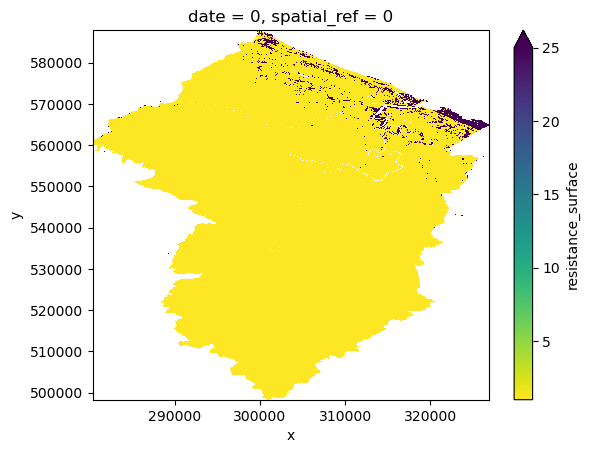

In [9]:
# raster de friction

resistance_raster = rout.create_resistance_surface(da_lc, specie['friction'])
resistance_raster.plot(robust=True, cmap='viridis_r') 

## 4.1. Network metrics: PC

By comparing the Theoretical PC (Euclidean from Graph) with the Real PC (LCP), we quantify the connectivity loss. This delta quantifies the impact of human infrastructure and urban matrix on species mobility.

### 4.1.1. LCP0 - no filters

In [ ]:
gdf_lcp0 = rout.compute_lcp_network(gdf_edges, df_nodes, da_lc, specie['friction'])

gdf_lcp0['tortuosity'] = gdf_lcp0['real_dist'] / gdf_lcp0['theoretical_dist']
print(f"Average Tortuosity for {CITY}: {gdf_lcp0['tortuosity'].mean():.3f}")
print(f"Median Tortuosity for {CITY}: {gdf_lcp0['tortuosity'].median():.3f}")
# print(gdf_lcp0['tortuosity'].describe())

Tracing LCPs:   0%|          | 0/761 [00:00<?, ?it/s]

In [ ]:
pc_real0, G_lcp0 = conn.calculate_pc_index_lcp(G=G, total_area_km2=total_area_km2, species_params=specie, gdf_lcp=gdf_lcp0)
print(f"Theoretical PC (euclidian) : {pc_value:.6f}")
print(f"Real PC (LCP0) : {pc_real0:.6f}")
print(f"Fragmentation impact : {((pc_value - pc_real0) / pc_value)*100:.1f}% connectivity loss.")

### 4.1.2. LCP filtered - uncrossable barriers

In [ ]:
d0 = specie['graph']['d0']
threshold = 3 * d0
print(f"Seuil de filtre appliqué : {threshold:.0f}")

gdf_lcp = gdf_lcp0[gdf_lcp0['accumulated_cost'] <= threshold].copy()
print(f"Nombre de chemins 'absurdes' supprimés : {len(gdf_lcp0) - len(gdf_lcp)}")

In [ ]:
gdf_lcp['tortuosity'] = gdf_lcp['real_dist'] / gdf_lcp['theoretical_dist']
print(f"Average Tortuosity for {CITY}: {gdf_lcp['tortuosity'].mean():.3f}")
print(f"Median Tortuosity for {CITY}: {gdf_lcp['tortuosity'].median():.3f}")
# print(gdf_lcp['tortuosity'].describe())

In [ ]:
pc_real, G_lcp = conn.calculate_pc_index_lcp(G, total_area_km2, specie, gdf_lcp)
print(f"Theoretical PC (euclidian) : {pc_value:.6f}")
print(f"Real PC (LCP) : {pc_real:.6f}")
print(f"Fragmentation impact : {((pc_value - pc_real) / pc_value)*100:.1f}% connectivity loss.")

In [ ]:
viz.plot_connectivity_ruptures(gdf_lcp0, gdf_lcp, aoi_utm, df_nodes, G_lcp)

## 4.2. Corridors metrics: dPC, ebc

Identify critical links for network maintenance using two complementary metrics: 
- dPC (Flux): Ranks corridors by the volume of biodiversity flow they facilitate. Based on the overall PC index, measures the contribution of a single link to the total probability of connectivity across the landscape. Weighted by the surface area of the habitats connected, and dispersal probability between them. Prioritizes quantity (link between 2 massive reservoirs).
- Edge Betweenness Centrality (Rarity) : Highlights bottlenecks / bridge corridors vital for network cohesion. Measures how often a specific corridor is used as a "shortest path" to connect all possible pairs of habitats in the network. Their loss would fragment the system into isolated sub-units, they act as the only available path between distant parts of the network, regardless of the size of the patches they link. 

In [21]:
### LCP0
# dpc flux
gdf_lcp0 = conn.calculate_edge_dpc(gdf_lcp0, G_lcp0, total_area_km2, pc_real)
# edge betweenness centrality proxy dpc edge connector
gdf_lcp0 = conn.calculate_edge_betweenness(gdf_lcp0, G_lcp0)

### LCP
# dpc flux
gdf_lcp = conn.calculate_edge_dpc(gdf_lcp, G_lcp, total_area_km2, pc_real)
# edge betweenness centrality proxy dpc edge connector
gdf_lcp = conn.calculate_edge_betweenness(gdf_lcp, G_lcp)

### 4.2.1. Corridors categories

| Flow (dPC) | Rarity (EBC) | Corridor category |  
| :--- | :--- | :--- |   
| **High** | **High** | Ecological highway |  
| **Low** | **High** | Strategic bottleneck |  
| **High** | **Low** | Redundant mesh |  
| **Low** | **Low** | Local link |  

In [22]:
### LCP0
gdf_lcp0 = conn.classify_corridors(gdf_lcp0, 0.75)
lcp_all = gdf_lcp0.set_index(['node_1', 'node_2'])
lcp_clean = gdf_lcp.set_index(['node_1', 'node_2'])
rupture_corridors = lcp_all.drop(lcp_clean.index, errors='ignore').reset_index()
# rupture_corridors.to_file(f"{OUTPUT_DIR}/barriers_{CITY}.json", driver='GeoJSON')

### LCP
gdf_lcp = conn.classify_corridors(gdf_lcp, 0.75)
# gdf_lcp.to_file(f"{OUTPUT_DIR}/lcp_{CITY}.json", driver='GeoJSON')

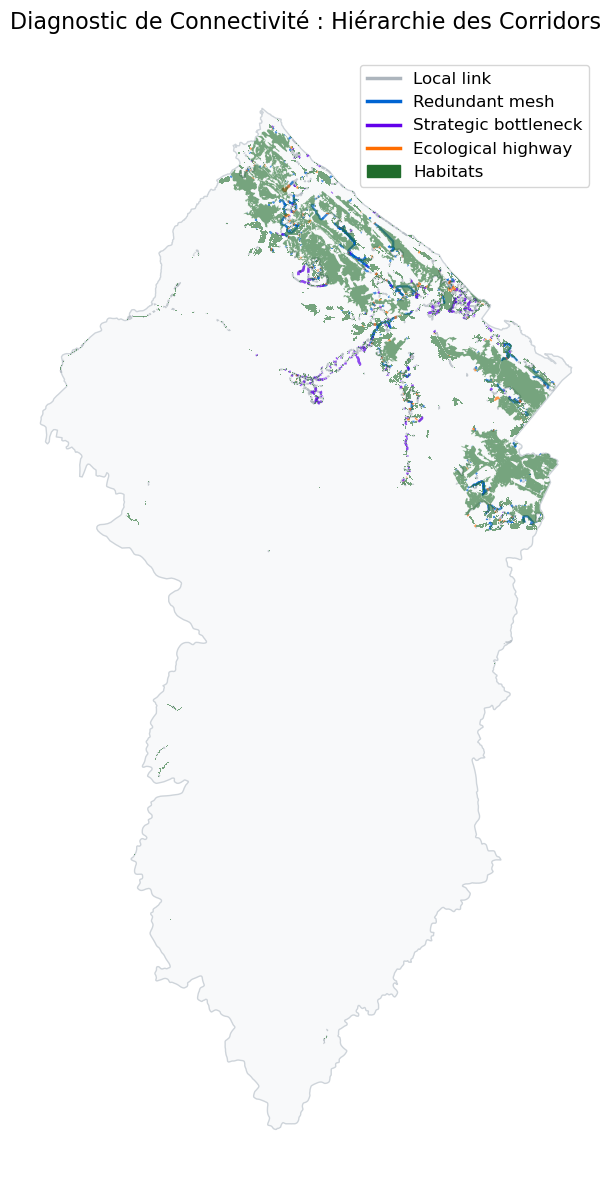

In [23]:
viz.plot_classified_corridors(gdf_lcp, df_nodes, aoi_utm)

### 4.2.2. Heatmap, connectivity density

In [24]:
da_heatmap = conn.lcp_heatmap(gdf_lcp, aoi_utm, res=10, crs_utm=utm_epsg)
# da_heatmap.rio.to_raster(f"{OUTPUT_DIR}/heatmap_lcp_{CITY}.tif")

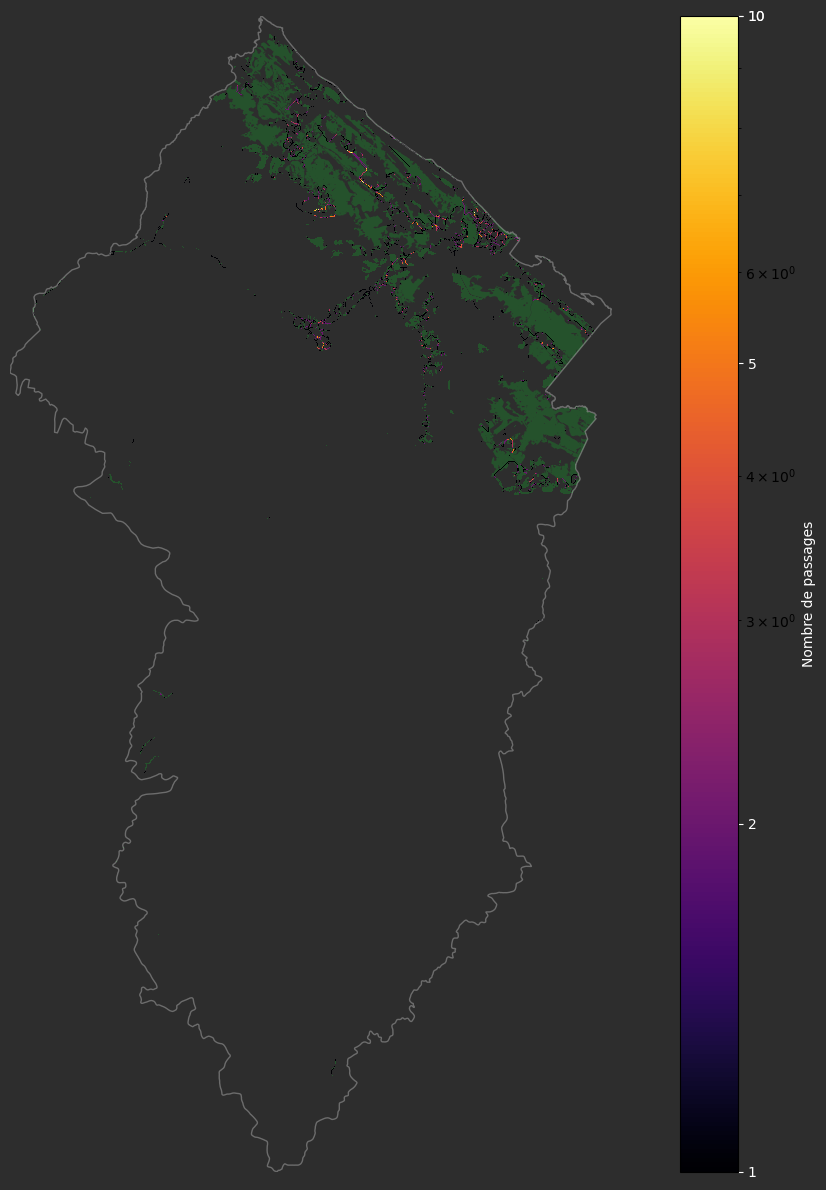

In [25]:
viz.plot_connectivity_heatmap(da_heatmap, df_nodes, aoi_utm, filter_size=4)

## 4.3. Nodes metrics: dPC

Analysis of the contribution of each patch to the global network. Connector fraction of the dPC index, which identifies patches that act as essential topological relays between other nodes, regardless of their own intrinsic area.
> warning : very long to compute, iterative node-removal simulations.

In [ ]:
# df_nodes_connector = conn.calculate_node_dpc(G_lcp, total_area_km2, species_params=specie)
# gdf_nodes = df_nodes.merge(df_nodes_connector, left_index=True, right_on='node_id')
# gdf_nodes.set_crs(utm_epsg, inplace=True, allow_override=True)
# gdf_nodes.to_file(f"{OUTPUT_DIR}/dpc_nodes_{CITY}.json", driver='GeoJSON')

______

# RUN EVERYTHING

run every step for all guilds, and save outputs in the folder associated  
run 0. configuration first

In [ ]:
guild_list = list(species_params.SPECIES_CONFIG.keys())

for guild_key in guild_list:
    try:
        run_guild_pipeline(guild_key, aoi_utm, da_lc, utm_epsg, aoi_raw, total_area_km2)
    except Exception as e:
        print(f"\n!!! Erreur fatale sur {guild_key} : {e}")

______

# WIP Circuit Theory

Proxy flou gaussien au lieu de lois de Kirchoff résistance pour chaque pixel  
Définir les sources et les grounds  
Use a Cost-Distance Accumulation surface instead of just a Gaussian blur to show where paths converge.

## 5.1. Carte de conductance

In [295]:
# 1. Récupération de la friction spécifique à la guilde
friction_dict = specie['friction']

# 2. Création de la carte de friction (Reclassement)
# On initialise avec une valeur par défaut élevée pour les codes inconnus
da_friction = xr.where(da_lc.isnull(), 1000, 1000) 

for code, weight in friction_dict.items():
    da_friction = xr.where(da_lc == code, weight, da_friction)

# 3. Calcul de la Conductance brute (1 / Friction)
da_conductance = 1.0 / (da_friction + 0.1)

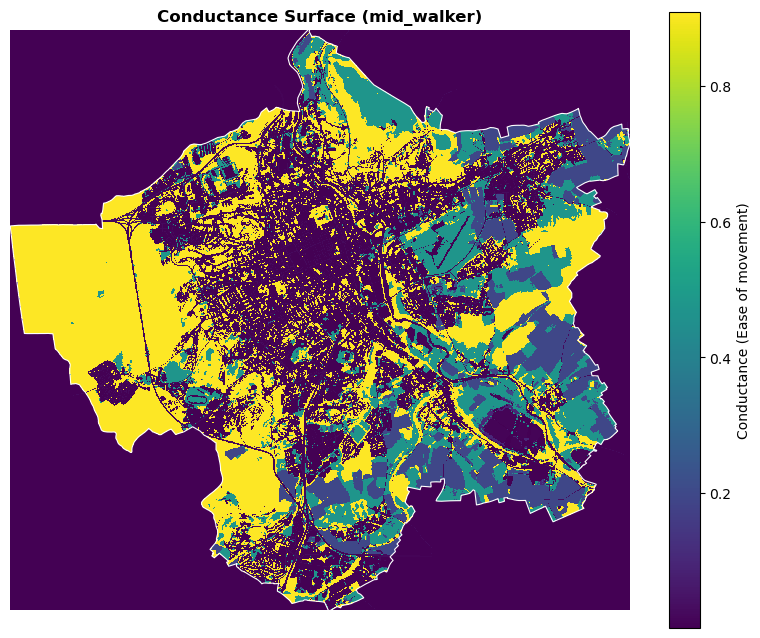

In [296]:
fig, ax = plt.subplots(figsize=(10, 8))

da_conductance.plot(
    ax=ax, 
    cmap='viridis', # jaune = passage facile, violet = barrière
    cbar_kwargs={'label': 'Conductance (Ease of movement)'}
)

aoi_utm.boundary.plot(ax=ax, color='white', linewidth=0.8)

ax.set_title(f"Conductance Surface ({GUILD_KEY})", fontweight='bold')
ax.set_axis_off()
plt.show()

## 5.2. Pinch points

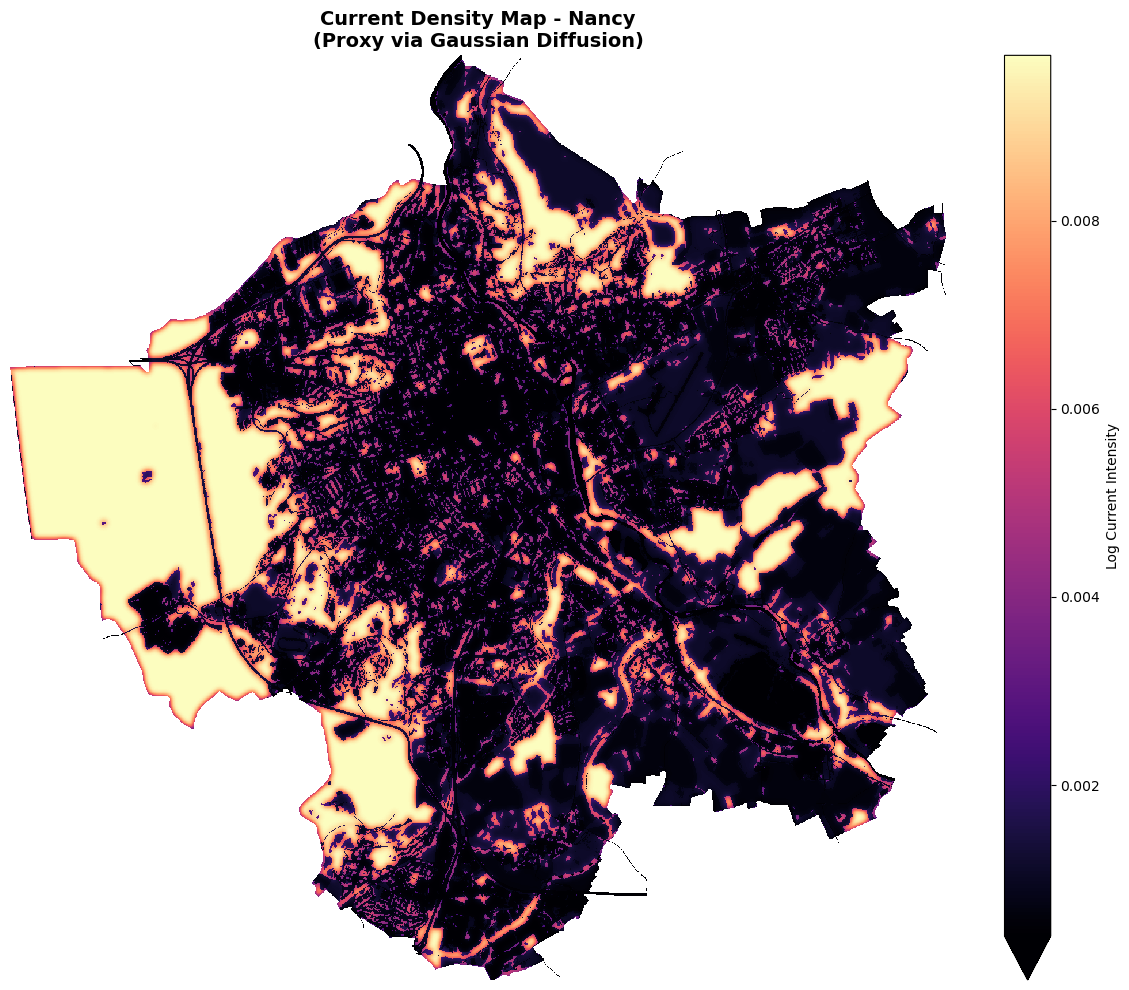

In [157]:
from scipy.ndimage import gaussian_filter

def calculate_pinch_points_proxy(da_friction, sigma=5):
    # Gestion des NaNs
    mask = da_friction.isnull()
    clean_friction = da_friction.fillna(da_friction.max())
    
    # 1. Conductance (Inverse de la friction)
    conductance = 1.0 / (clean_friction + 0.1)
    
    # 2. Diffusion proxy (Sigma plus élevé pour mieux voir les corridors)
    flow_spread = gaussian_filter(conductance.values, sigma=sigma)
    
    # Intensité de courant
    current_density = flow_spread * conductance.values
    
    da_current = da_friction.copy(data=current_density)
    return da_current.where(~mask)

# 1. Calcul
da_current_map = calculate_pinch_points_proxy(da_lc, sigma=5)

# 2. Visualisation simple
fig, ax = plt.subplots(figsize=(12, 10))

# On utilise log1p pour compresser la dynamique et voir les détails urbains
np.log1p(da_current_map).plot(
    ax=ax, 
    cmap='magma', 
    robust=True, 
    cbar_kwargs={'label': 'Log Current Intensity'}
)

ax.set_title(f"Current Density Map - {CITY}\n(Proxy via Gaussian Diffusion)", fontsize=14, fontweight='bold')
ax.set_axis_off()

plt.tight_layout()
plt.show()